# 06 - Four-Model Comparison

This notebook compares only saved evaluation artifacts for the MLP / DNN, Denoising Autoencoder + Classifier, TabNet, and FT-Transformer. It does not load model checkpoints, load the raw dataset, run inference, or retrain any model.

## Load and validate saved artifacts

In [5]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_ROOT = PROJECT / 'results'
COMPARISON_DIR = RESULTS_ROOT / 'model_comparison'
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIRS = {
    'MLP / DNN': RESULTS_ROOT / 'mlp',
    'Denoising Autoencoder + Classifier': RESULTS_ROOT / 'autoencoder',
    'TabNet': RESULTS_ROOT / 'tabnet',
    'FT-Transformer': RESULTS_ROOT / 'ft_transformer',
}
EXPECTED_MODELS = set(MODEL_DIRS)
EXPECTED_CLASS_ORDER = [
    'BENIGN', 'Botnet', 'Brute Force', 'DDoS', 'DoS',
    'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack',
]

required_files = ['metrics.json', 'per_class_metrics.csv']
for model_name, model_dir in MODEL_DIRS.items():
    missing_files = [file_name for file_name in required_files if not (model_dir / file_name).exists()]
    if missing_files:
        raise FileNotFoundError(f'{model_name} is missing: {missing_files}')

artifacts = {}
for expected_name, model_dir in MODEL_DIRS.items():
    metrics = json.loads((model_dir / 'metrics.json').read_text(encoding='utf-8'))
    actual_name = metrics.get('model')
    if actual_name != expected_name:
        raise ValueError(f'Model name mismatch for {model_dir}: expected {expected_name!r}, got {actual_name!r}')
    per_class = pd.read_csv(model_dir / 'per_class_metrics.csv')
    class_column = 'class' if 'class' in per_class.columns else per_class.columns[0]
    class_order = per_class[class_column].tolist()
    if class_order != EXPECTED_CLASS_ORDER:
        raise ValueError(f'Class order mismatch for {expected_name}: {class_order}')
    artifacts[expected_name] = {
        'metrics': metrics,
        'per_class': per_class.assign(class_name=per_class[class_column]).drop(columns=[class_column]),
    }

if set(artifacts) != EXPECTED_MODELS:
    raise ValueError(f'Model set mismatch: {set(artifacts)}')

validation_table = pd.DataFrame({
    'model': list(artifacts),
    'saved_metrics_model_name': [artifacts[name]['metrics']['model'] for name in artifacts],
    'class_count': [len(artifacts[name]['per_class']) for name in artifacts],
    'class_order_verified': [True] * len(artifacts),
})
validation_table.to_csv(COMPARISON_DIR / 'artifact_validation.csv', index=False)
display(validation_table)
print('Validated four saved result directories and the shared nine-class order.')

,model,saved_metrics_model_name,class_count,class_order_verified
0,MLP / DNN,MLP / DNN,9,True
1,Denoising Autoencoder + Classifier,Denoising Autoencoder + Classifier,9,True
2,TabNet,TabNet,9,True
3,FT-Transformer,FT-Transformer,9,True


Validated four saved result directories and the shared nine-class order.


## Normalize scalar metrics

In [6]:
MULTICLASS_FIELDS = [
    'accuracy', 'macro_precision', 'macro_recall', 'macro_f1',
    'weighted_f1', 'balanced_accuracy',
]
BINARY_FIELDS = [
    'precision', 'recall_detection_rate', 'f1', 'roc_auc',
    'pr_auc', 'false_positive_rate', 'mcc',
]

def first_present(mapping, keys):
    for key in keys:
        if key in mapping:
            return mapping[key]
    return np.nan

performance_rows = []
binary_rows = []
efficiency_rows = []
for model_name, artifact in artifacts.items():
    metrics = artifact['metrics']
    multiclass = metrics.get('multiclass', {})
    binary = metrics.get('binary_benign_vs_attack', metrics.get('binary', {}))
    efficiency = metrics.get('efficiency', {})
    performance_rows.append({
        'model': model_name,
        **{field: multiclass.get(field, np.nan) for field in MULTICLASS_FIELDS},
    })
    binary_rows.append({
        'model': model_name,
        **{field: binary.get(field, np.nan) for field in BINARY_FIELDS},
    })
    efficiency_rows.append({
        'model': model_name,
        'parameter_count': first_present(efficiency, ['trainable_parameters', 'total_parameters']),
        'model_size_mb': first_present(efficiency, ['model_file_mb']),
        'training_time_seconds': first_present(efficiency, ['training_seconds', 'total_training_seconds']),
        'inference_time_seconds': first_present(efficiency, ['inference_seconds', 'test_inference_seconds']),
        'device': efficiency.get('device', 'Unavailable'),
    })

performance_table = pd.DataFrame(performance_rows).set_index('model')
binary_table = pd.DataFrame(binary_rows).set_index('model')
efficiency_table = pd.DataFrame(efficiency_rows).set_index('model')

performance_table.to_csv(COMPARISON_DIR / 'multiclass_performance.csv')
binary_table.to_csv(COMPARISON_DIR / 'binary_performance.csv')
efficiency_table.to_csv(COMPARISON_DIR / 'efficiency.csv')

display(performance_table.style.format('{:.4f}'))
display(binary_table.style.format('{:.4f}'))
display(efficiency_table)

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy
model,,,,,,
MLP / DNN,0.9374,0.4773,0.9541,0.5531,0.9490,0.9541
Denoising Autoencoder + Classifier,0.9282,0.5336,0.9685,0.6034,0.9434,0.9685
TabNet,0.9718,0.6641,0.9446,0.7158,0.9750,0.9446
FT-Transformer,0.9544,0.5980,0.9735,0.6568,0.9654,0.9735


,precision,recall_detection_rate,f1,roc_auc,pr_auc,false_positive_rate,mcc
model,,,,,,,
MLP / DNN,0.7315,0.9975,0.8440,0.9956,0.9786,0.0744,0.8214
Denoising Autoencoder + Classifier,0.7045,0.9987,0.8262,0.9955,0.9794,0.0851,0.8021
TabNet,0.8579,0.9988,0.9230,0.9978,0.9897,0.0336,0.9099
FT-Transformer,0.7884,0.9991,0.8813,0.9968,0.9858,0.0545,0.8629


,parameter_count,model_size_mb,training_time_seconds,inference_time_seconds,device
model,,,,,
MLP / DNN,59657,0.231118,NaN,0.407840,cpu
Denoising Autoencoder + Classifier,43694,0.181890,1692.612665,4.067853,cpu
TabNet,29042,0.121584,1350.813929,7.491955,cpu
FT-Transformer,114185,0.451648,3120.000000,268.996939,cpu


## Multiclass performance

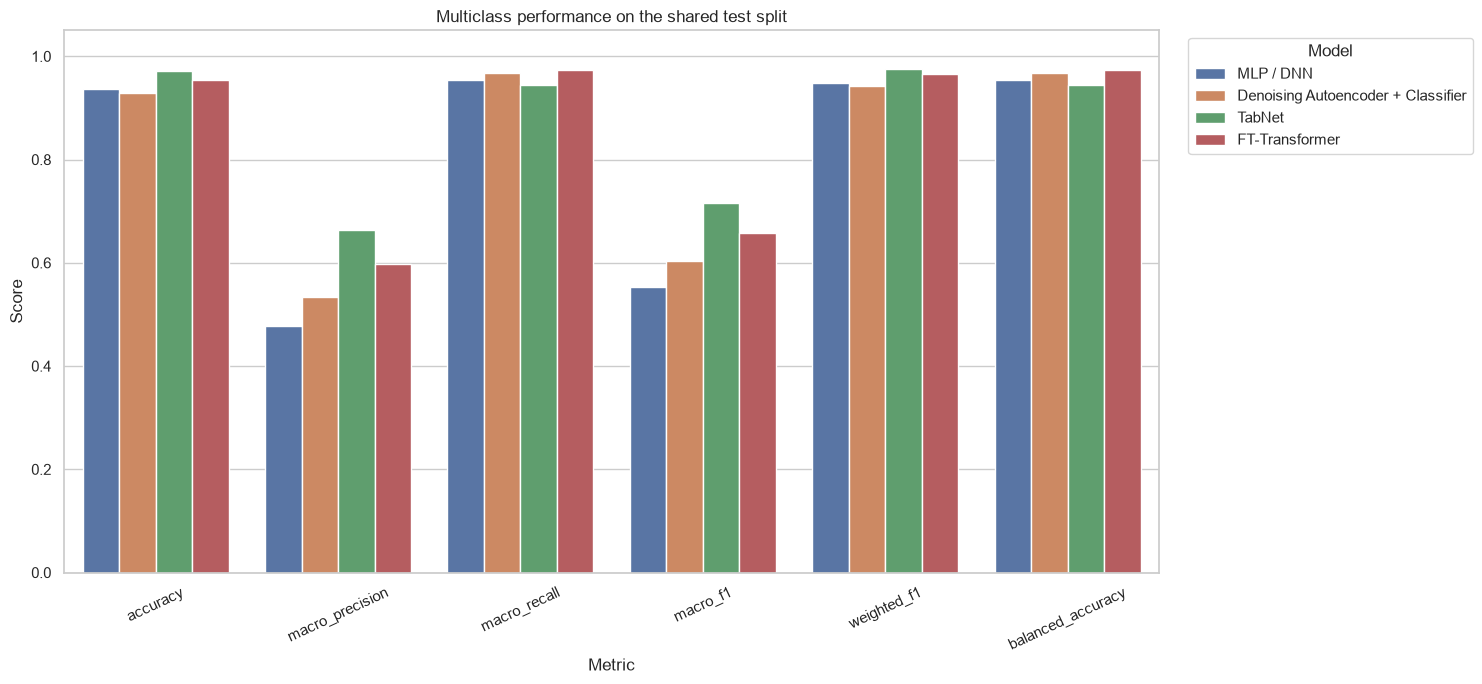

In [7]:
sns.set_theme(style='whitegrid')
performance_long = performance_table.reset_index().melt(
    id_vars='model', var_name='metric', value_name='score',
)
figure, axis = plt.subplots(figsize=(15, 7))
sns.barplot(data=performance_long, x='metric', y='score', hue='model', ax=axis)
axis.set_title('Multiclass performance on the shared test split')
axis.set_ylabel('Score')
axis.set_xlabel('Metric')
axis.set_ylim(0, 1.05)
axis.tick_params(axis='x', rotation=25)
axis.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
figure.tight_layout()
figure.savefig(COMPARISON_DIR / 'multiclass_performance.png', dpi=160)
plt.show()

## Binary intrusion detection

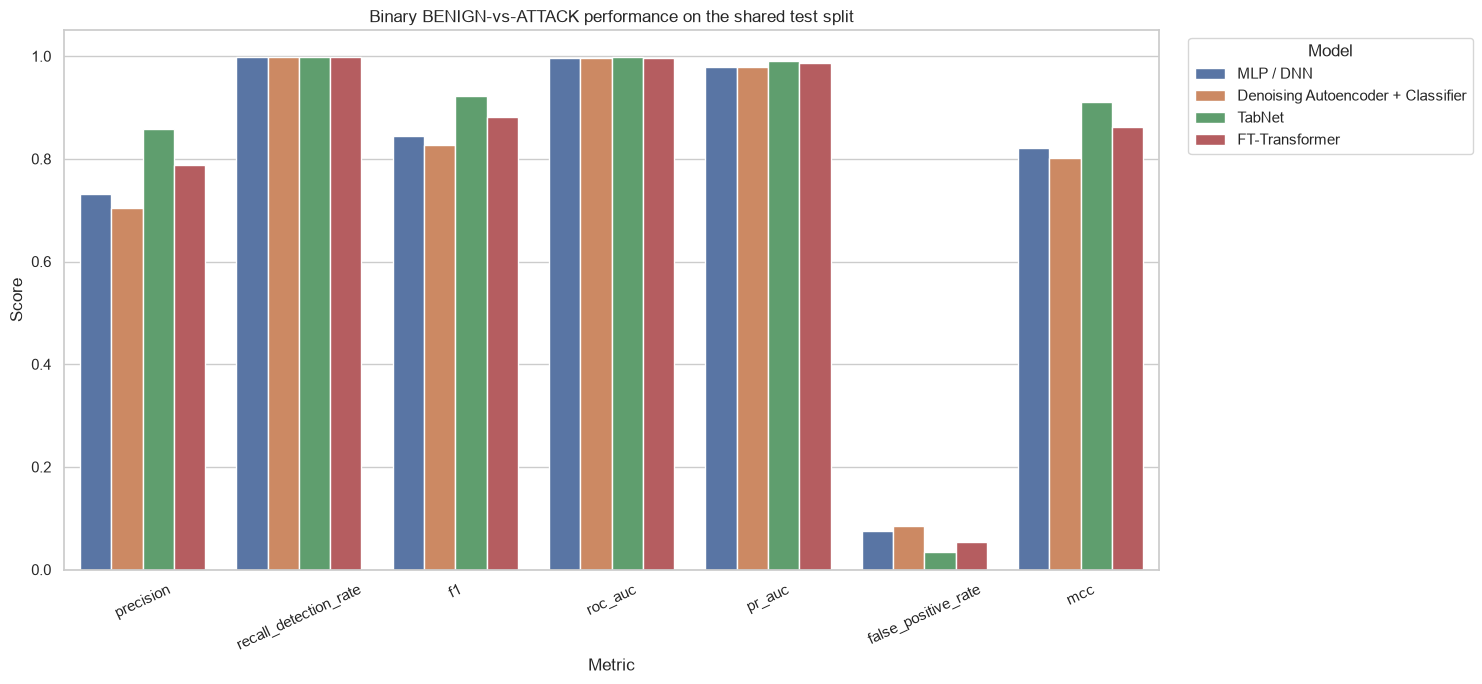

In [8]:
binary_long = binary_table.reset_index().melt(
    id_vars='model', var_name='metric', value_name='score',
)
figure, axis = plt.subplots(figsize=(15, 7))
sns.barplot(data=binary_long, x='metric', y='score', hue='model', ax=axis)
axis.set_title('Binary BENIGN-vs-ATTACK performance on the shared test split')
axis.set_ylabel('Score')
axis.set_xlabel('Metric')
axis.set_ylim(0, 1.05)
axis.tick_params(axis='x', rotation=25)
axis.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
figure.tight_layout()
figure.savefig(COMPARISON_DIR / 'binary_performance.png', dpi=160)
plt.show()

## Efficiency

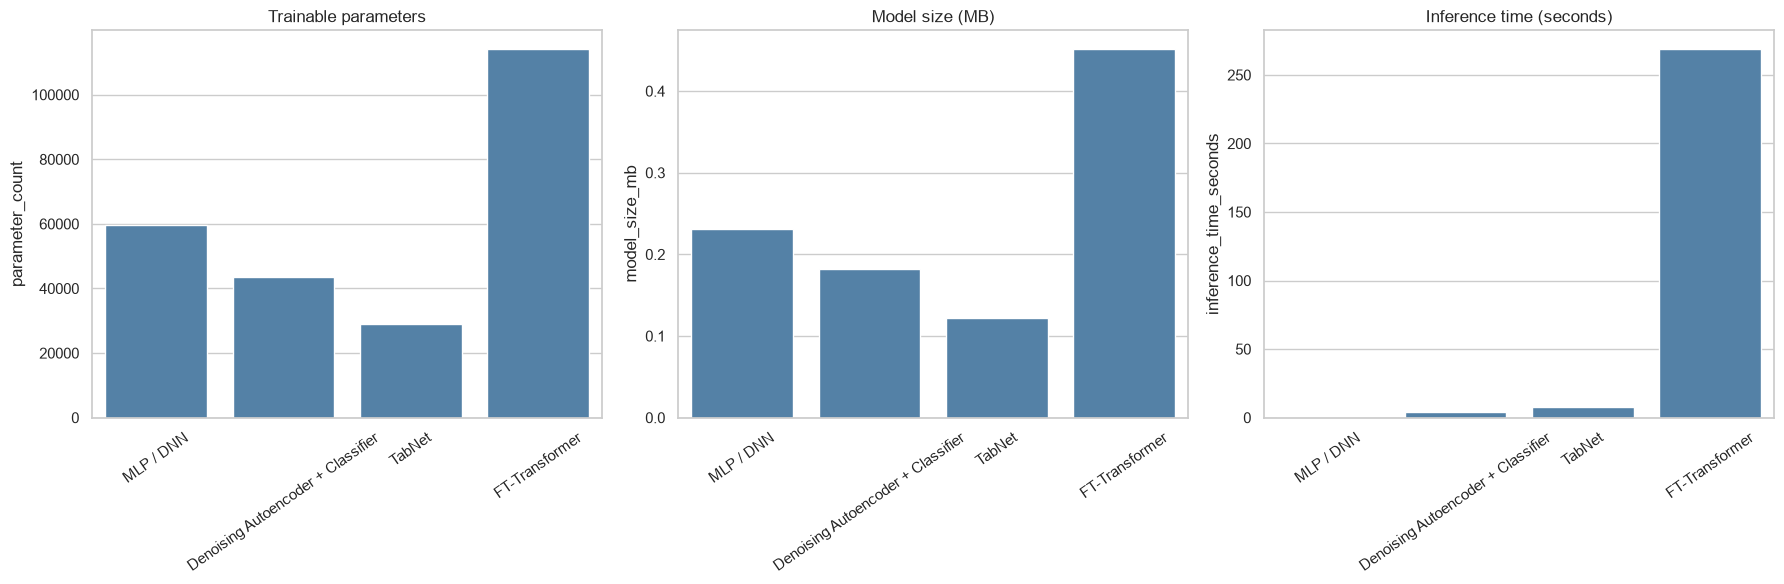

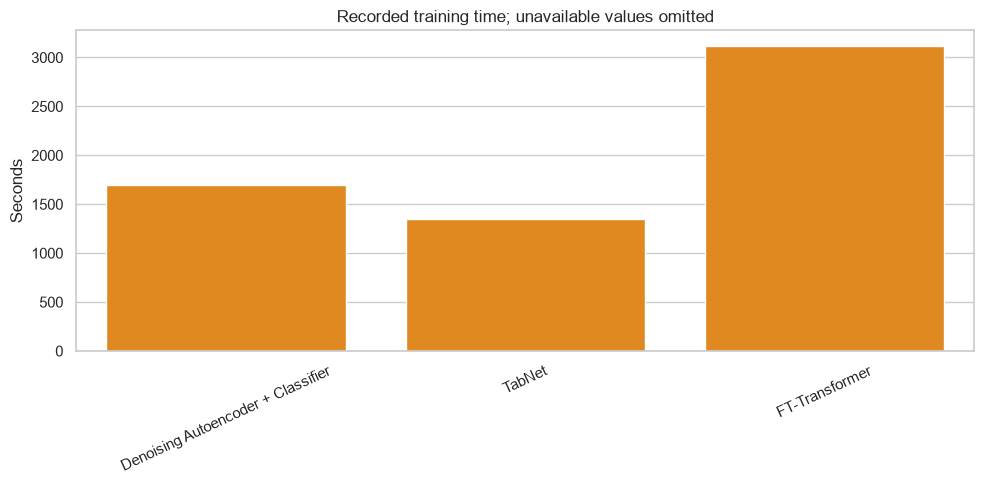

In [9]:
efficiency_plot_data = efficiency_table.reset_index().melt(
    id_vars=['model', 'device'],
    value_vars=['parameter_count', 'model_size_mb', 'inference_time_seconds', 'training_time_seconds'],
    var_name='metric', value_name='value',
)
figure, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_specs = [
    ('parameter_count', 'Trainable parameters'),
    ('model_size_mb', 'Model size (MB)'),
    ('inference_time_seconds', 'Inference time (seconds)'),
]
for axis, (metric, title) in zip(axes, plot_specs):
    plot_data = efficiency_table.reset_index()[['model', metric]].dropna()
    sns.barplot(data=plot_data, x='model', y=metric, ax=axis, color='steelblue')
    axis.set_title(title)
    axis.set_xlabel('')
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='x', visible=False)
figure.tight_layout()
figure.savefig(COMPARISON_DIR / 'efficiency.png', dpi=160)
plt.show()

training_plot = efficiency_table[['training_time_seconds']].dropna().reset_index()
if training_plot.empty:
    print('Training-time plot unavailable: all saved training times are missing.')
else:
    figure, axis = plt.subplots(figsize=(10, 5))
    sns.barplot(data=training_plot, x='model', y='training_time_seconds', ax=axis, color='darkorange')
    axis.set_title('Recorded training time; unavailable values omitted')
    axis.set_xlabel('')
    axis.set_ylabel('Seconds')
    axis.tick_params(axis='x', rotation=25)
    figure.tight_layout()
    figure.savefig(COMPARISON_DIR / 'training_time_available_values.png', dpi=160)
    plt.show()

## Per-class recall and F1

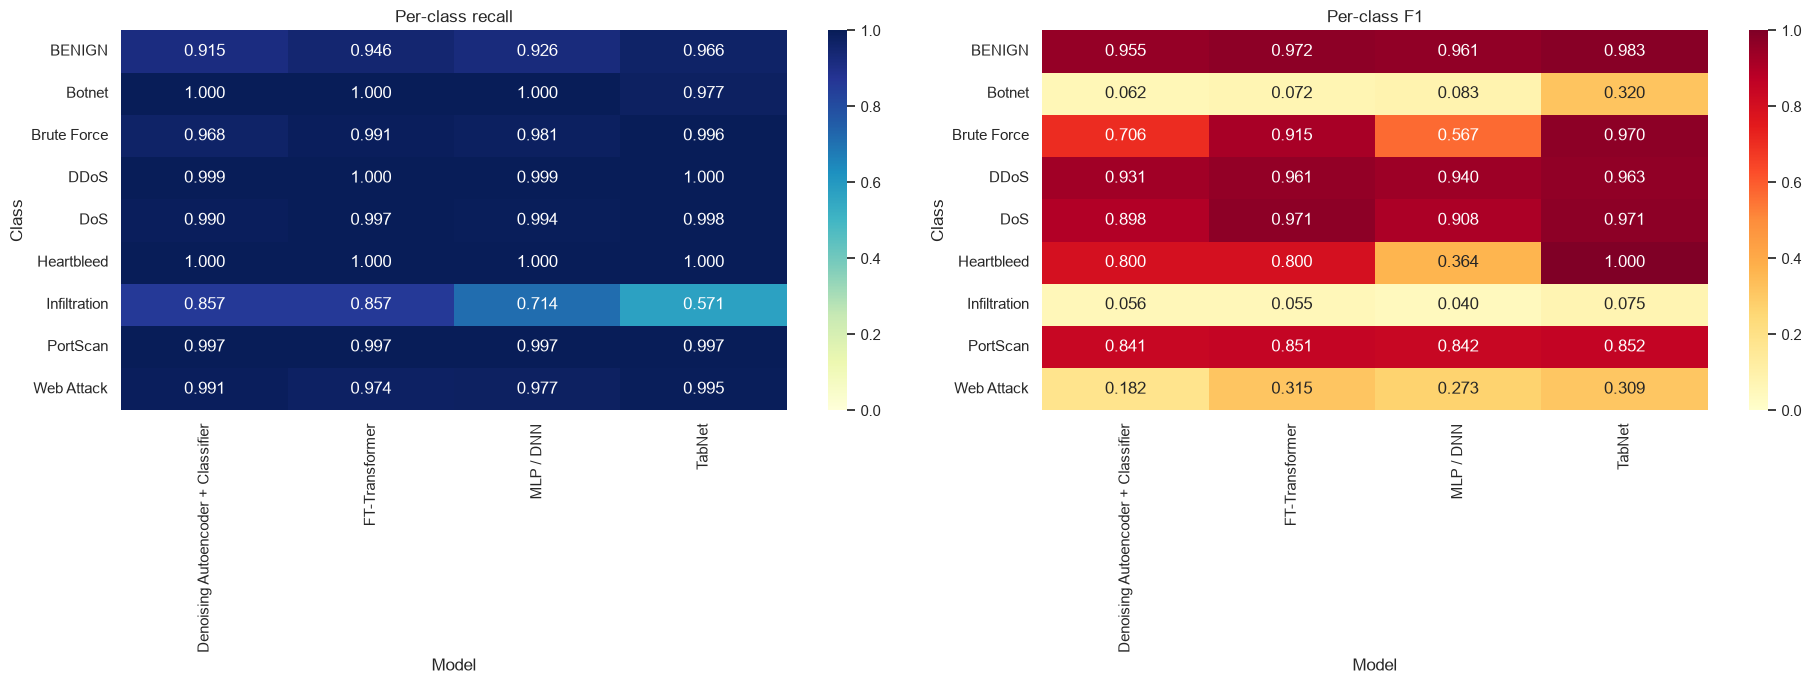

model,Denoising Autoencoder + Classifier,FT-Transformer,MLP / DNN,TabNet
class_name,,,,
BENIGN,0.9149,0.9455,0.9256,0.9664
Botnet,1.0000,1.0000,1.0000,0.9770
Brute Force,0.9678,0.9907,0.9814,0.9962
DDoS,0.9991,0.9999,0.9989,0.9997
DoS,0.9898,0.9974,0.9937,0.9979
Heartbleed,1.0000,1.0000,1.0000,1.0000
Infiltration,0.8571,0.8571,0.7143,0.5714
PortScan,0.9973,0.9967,0.9967,0.9971
Web Attack,0.9907,0.9744,0.9767,0.9953


model,Denoising Autoencoder + Classifier,FT-Transformer,MLP / DNN,TabNet
class_name,,,,
BENIGN,0.9554,0.9719,0.9611,0.9828
Botnet,0.0624,0.0725,0.0830,0.3198
Brute Force,0.7060,0.9145,0.5675,0.9697
DDoS,0.9305,0.9609,0.9400,0.9629
DoS,0.8981,0.9709,0.9079,0.9713
Heartbleed,0.8000,0.8000,0.3636,1.0000
Infiltration,0.0556,0.0553,0.0400,0.0755
PortScan,0.8407,0.8507,0.8419,0.8518
Web Attack,0.1822,0.3150,0.2732,0.3086


In [10]:
per_class_frames = []
for model_name, artifact in artifacts.items():
    frame = artifact['per_class'][['class_name', 'recall', 'f1']].copy()
    frame['model'] = model_name
    per_class_frames.append(frame)
per_class_table = pd.concat(per_class_frames, ignore_index=True)
per_class_table.to_csv(COMPARISON_DIR / 'per_class_comparison.csv', index=False)

recall_table = per_class_table.pivot(index='class_name', columns='model', values='recall').reindex(EXPECTED_CLASS_ORDER)
f1_table = per_class_table.pivot(index='class_name', columns='model', values='f1').reindex(EXPECTED_CLASS_ORDER)
recall_table.to_csv(COMPARISON_DIR / 'per_class_recall.csv')
f1_table.to_csv(COMPARISON_DIR / 'per_class_f1.csv')

figure, axes = plt.subplots(1, 2, figsize=(19, 7))
sns.heatmap(recall_table, annot=True, fmt='.3f', vmin=0, vmax=1, cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Per-class recall')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Class')
sns.heatmap(f1_table, annot=True, fmt='.3f', vmin=0, vmax=1, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Per-class F1')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Class')
figure.tight_layout()
figure.savefig(COMPARISON_DIR / 'per_class_recall_f1.png', dpi=160)
plt.show()

display(recall_table.style.format('{:.4f}'))
display(f1_table.style.format('{:.4f}'))

## Automatically generated factual summary

In [11]:
best_macro_f1_model = performance_table['macro_f1'].idxmax()
best_macro_f1 = performance_table.loc[best_macro_f1_model, 'macro_f1']
best_binary_f1_model = binary_table['f1'].idxmax()
best_binary_f1 = binary_table.loc[best_binary_f1_model, 'f1']
lowest_fpr_model = binary_table['false_positive_rate'].idxmin()
lowest_fpr = binary_table.loc[lowest_fpr_model, 'false_positive_rate']
smallest_model = efficiency_table['parameter_count'].idxmin()
smallest_parameter_count = efficiency_table.loc[smallest_model, 'parameter_count']
fastest_inference_model = efficiency_table['inference_time_seconds'].idxmin()
fastest_inference = efficiency_table.loc[fastest_inference_model, 'inference_time_seconds']
missing_training_time = efficiency_table.index[efficiency_table['training_time_seconds'].isna()].tolist()
device_summary = ', '.join(sorted(efficiency_table['device'].astype(str).unique()))
missing_training_summary = ', '.join(missing_training_time) if missing_training_time else 'none'

summary_lines = [
    f'- Highest saved multiclass macro-F1: {best_macro_f1_model} ({best_macro_f1:.4f}).',
    f'- Highest saved binary BENIGN-vs-ATTACK F1: {best_binary_f1_model} ({best_binary_f1:.4f}).',
    f'- Lowest saved binary false-positive rate: {lowest_fpr_model} ({lowest_fpr:.4f}).',
    f'- Smallest saved trainable parameter count: {smallest_model} ({smallest_parameter_count:,.0f}).',
    f'- Lowest saved full-test inference time: {fastest_inference_model} ({fastest_inference:.4f} seconds).',
    f'- Recorded evaluation devices: {device_summary}.',
    f'- Training time is unavailable for: {missing_training_summary}.',
    '- These observations describe the saved artifacts and do not establish causal reasons for the differences.',
]
summary_text = '\n'.join(summary_lines)
(COMPARISON_DIR / 'summary.md').write_text(
    '# Four-Model Comparison Summary\n\n' + summary_text + '\n',
    encoding='utf-8',
)
display(Markdown('\n'.join(summary_lines)))

- Highest saved multiclass macro-F1: TabNet (0.7158).
- Highest saved binary BENIGN-vs-ATTACK F1: TabNet (0.9230).
- Lowest saved binary false-positive rate: TabNet (0.0336).
- Smallest saved trainable parameter count: TabNet (29,042).
- Lowest saved full-test inference time: MLP / DNN (0.4078 seconds).
- Recorded evaluation devices: cpu.
- Training time is unavailable for: MLP / DNN.
- These observations describe the saved artifacts and do not establish causal reasons for the differences.

## Critical Comparison Evidence

The following saved tables provide the report evidence for macro-F1, minority-class recall/F1, binary false-positive rate, parameter count, inference cost, device, and the explicitly unavailable MLP training time.

In [12]:
critical_evidence = pd.DataFrame({
    'macro_f1': performance_table['macro_f1'],
    'binary_f1': binary_table['f1'],
    'binary_false_positive_rate': binary_table['false_positive_rate'],
    'parameter_count': efficiency_table['parameter_count'],
    'model_size_mb': efficiency_table['model_size_mb'],
    'inference_time_seconds': efficiency_table['inference_time_seconds'],
    'training_time_seconds': efficiency_table['training_time_seconds'],
    'device': efficiency_table['device'],
})
critical_evidence.to_csv(COMPARISON_DIR / 'critical_comparison_evidence.csv')
display(critical_evidence.style.format({
    'macro_f1': '{:.4f}',
    'binary_f1': '{:.4f}',
    'binary_false_positive_rate': '{:.4f}',
    'parameter_count': '{:,.0f}',
    'model_size_mb': '{:.4f}',
    'inference_time_seconds': '{:.4f}',
    'training_time_seconds': '{:.4f}',
}))
display(recall_table)
display(f1_table)
print(f'All comparison outputs saved under: {COMPARISON_DIR}')

,macro_f1,binary_f1,binary_false_positive_rate,parameter_count,model_size_mb,inference_time_seconds,training_time_seconds,device
model,,,,,,,,
MLP / DNN,0.5531,0.8440,0.0744,"59,657",0.2311,0.4078,nan,cpu
Denoising Autoencoder + Classifier,0.6034,0.8262,0.0851,"43,694",0.1819,4.0679,1692.6127,cpu
TabNet,0.7158,0.9230,0.0336,"29,042",0.1216,7.4920,1350.8139,cpu
FT-Transformer,0.6568,0.8813,0.0545,"114,185",0.4516,268.9969,3120.0000,cpu


model,Denoising Autoencoder + Classifier,FT-Transformer,MLP / DNN,TabNet
class_name,,,,
BENIGN,0.914917,0.945542,0.925611,0.966403
Botnet,1.000000,1.000000,1.000000,0.976982
Brute Force,0.967760,0.990710,0.981421,0.996175
DDoS,0.999063,0.999922,0.998867,0.999727
DoS,0.989806,0.997445,0.993703,0.997935
Heartbleed,1.000000,1.000000,1.000000,1.000000
Infiltration,0.857143,0.857143,0.714286,0.571429
PortScan,0.997302,0.996697,0.996697,0.997082
Web Attack,0.990676,0.974359,0.976690,0.995338


model,Denoising Autoencoder + Classifier,FT-Transformer,MLP / DNN,TabNet
class_name,,,,
BENIGN,0.955434,0.971915,0.961113,0.982797
Botnet,0.062425,0.072454,0.082971,0.319799
Brute Force,0.706000,0.914502,0.567457,0.969681
DDoS,0.930501,0.960854,0.940013,0.962907
DoS,0.898128,0.970862,0.907882,0.971315
Heartbleed,0.800000,0.800000,0.363636,1.000000
Infiltration,0.055556,0.055300,0.040000,0.075472
PortScan,0.840720,0.850692,0.841909,0.851761
Web Attack,0.182208,0.314996,0.273231,0.308638


All comparison outputs saved under: d:\Projects\SE4050-DL\results\model_comparison
